In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('dataset_ESAVI_limpo.csv')

# Fazendo a preparação dos dados (Binarização / Variáveis Dummy)
# Criei um novo DataFrame apenas com dados numéricos para a correlação
df_corr = pd.DataFrame()

In [2]:
# Idade já é número
df_corr['Idade'] = pd.to_numeric(df['Idade Evento'], errors='coerce')

# Transformando texto em 0 ou 1
df_corr['Sexo_Feminino'] = df['Sexo'].apply(lambda x: 1 if str(x).strip() == 'Feminino' else 0)
df_corr['Atendimento_Medico'] = df['Houve atendimento médico?'].apply(lambda x: 1 if str(x).strip() == 'Sim' else 0)
df_corr['Erro_Imunizacao'] = df['Tipo de Evento'].apply(lambda x: 1 if 'Erro de Imunização' in str(x) else 0)
df_corr['Evento_Adverso'] = df['Tipo de Evento'].apply(lambda x: 1 if 'Evento Adverso' in str(x) else 0)
df_corr['Raca_Branca'] = df['Raça/Cor'].apply(lambda x: 1 if str(x).strip() == 'Branca' else 0)
df_corr['Raca_Parda'] = df['Raça/Cor'].apply(lambda x: 1 if str(x).strip() == 'Parda' else 0)

In [3]:
# Calculando a Matriz de Correlação
matriz_correlacao = df_corr.corr()

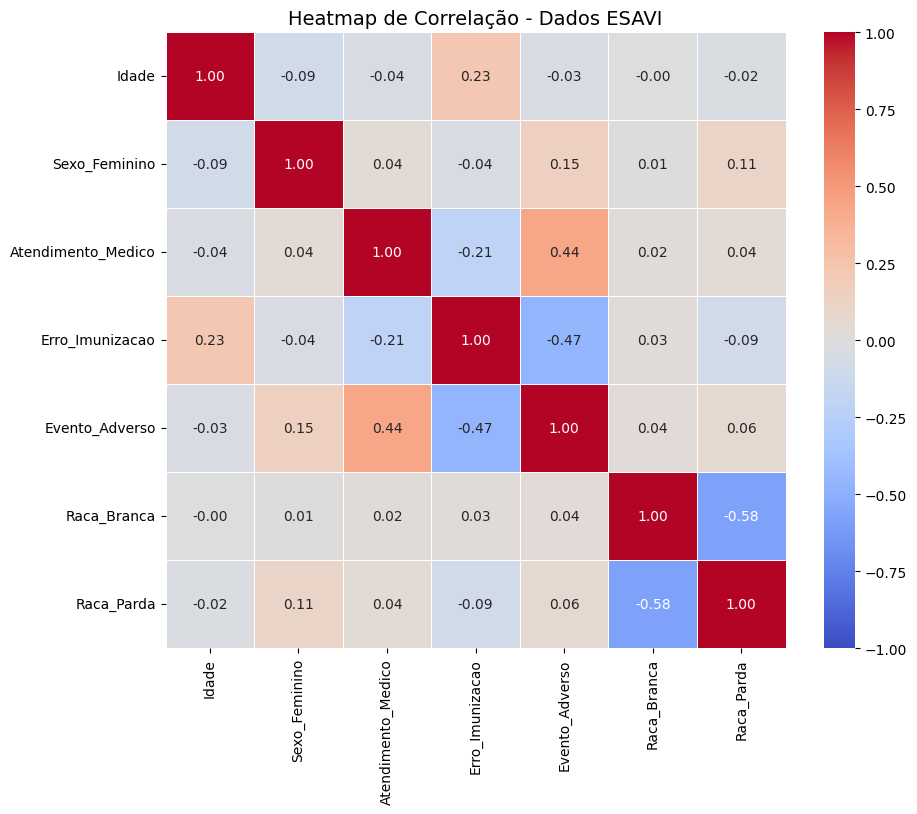

In [4]:
# Gerando o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Heatmap de Correlação - Dados ESAVI', fontsize=14)
plt.show()

In [5]:
# Identificando os pares fortes e fracos matematicamente
# Pego o valor absoluto para ignorar o sinal negativo/positivo na força
correlacoes_ordenadas = matriz_correlacao.abs().unstack().sort_values(ascending=False)

# Removo a correlação de uma variável com ela mesma (que é sempre 1.0) e remove duplicatas (A com B = B com A)
correlacoes_unicas = correlacoes_ordenadas[correlacoes_ordenadas < 1].drop_duplicates()

In [6]:
print("--- TOP 3 PARES FORTEMENTE CORRELACIONADOS ---")
print(correlacoes_unicas.head(3))

--- TOP 3 PARES FORTEMENTE CORRELACIONADOS ---
Raca_Branca         Raca_Parda         0.579915
Evento_Adverso      Erro_Imunizacao    0.467200
Atendimento_Medico  Evento_Adverso     0.435913
dtype: float64


In [7]:
print("\n--- TOP 3 PARES FRACAMENTE CORRELACIONADOS ---")
print(correlacoes_unicas.tail(3))


--- TOP 3 PARES FRACAMENTE CORRELACIONADOS ---
Idade        Raca_Parda       0.024195
Raca_Branca  Sexo_Feminino    0.012218
Idade        Raca_Branca      0.004289
dtype: float64
